# Неделя 6. Декомпозиция для прогнозирования

Разложение само ничего не прогнозирует, но его компоненты полезны в трёх ролях:
1. **остаток** $R$ — то, что не объяснили тренд и сезонность → поиск **аномалий**;
2. **$y - S$** — ряд без сезонности проще прогнозировать, а $S$ прогнозируется отдельно → **удаление компонент**;
3. **$T, S_{24}, S_{168}$** — готовые регрессоры → **признаки** для другой модели.

Общая ловушка — **утечка**. STL и MSTL двусторонние: LOESS в точке $t$ использует
наблюдения после $t$. Поэтому при оценке прогноза разложение считаем только на train.

In [1]:
import time
import warnings
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
from statsforecast import StatsForecast
from statsforecast.feature_engineering import mstl_decomposition
from statsforecast.models import ARIMA, MSTL, AutoARIMA, RandomWalkWithDrift, SeasonalNaive
from statsmodels.datasets import elec_equip
from statsmodels.tsa.arima.model import ARIMA as SMARIMA
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.forecasting.stl import STLForecast
from statsmodels.tsa.seasonal import MSTL as SMMSTL
from statsmodels.tsa.seasonal import STL
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mase, rmse
from utilsforecast.plotting import plot_series

warnings.simplefilter("ignore")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
pd.set_option("display.precision", 1)

## Данные

- **PJME** — почасовая нагрузка энергосистемы (тот же отрезок, что в ноутбуке 01).
  Для statsforecast — в длинном формате `unique_id, ds, y`.
- **elec_equip** — месячный индекс производства электрооборудования.
- **AirPassengers** — месячный, мультипликативная сезонность.

In [2]:
air = pd.read_csv("../data/air_passengers.csv", index_col="Month", parse_dates=True)["#Passengers"].asfreq("MS")
elec = elec_equip.load().data.iloc[:, 0].asfreq("MS")

pjme = (
    pd.read_csv("../data/PJME_hourly.csv", parse_dates=["Datetime"])
    .groupby("Datetime")["PJME_MW"].mean()  # 4 дубля
    .asfreq("h")
    .interpolate()  # 30 пропусков
    .loc["2015-08-03":"2018-08-02"]
)

# формат statsforecast; для прогнозов берём последние 4 месяца
df = pjme.rename("y").rename_axis("ds").reset_index().assign(unique_id="PJME")[["unique_id", "ds", "y"]]
df = df[df["ds"] >= "2018-04-01"].reset_index(drop=True)
len(pjme), len(df)

(26304, 2976)

## 1. Поиск аномалий

Аномалия — наблюдение, которое не объясняется обычной структурой ряда.
Порог по самому ряду не работает: сезонный пик выше любой аномалии.
Правило $\mu \pm 3\sigma$ по $y$ отмечает только самые жаркие часы лета.

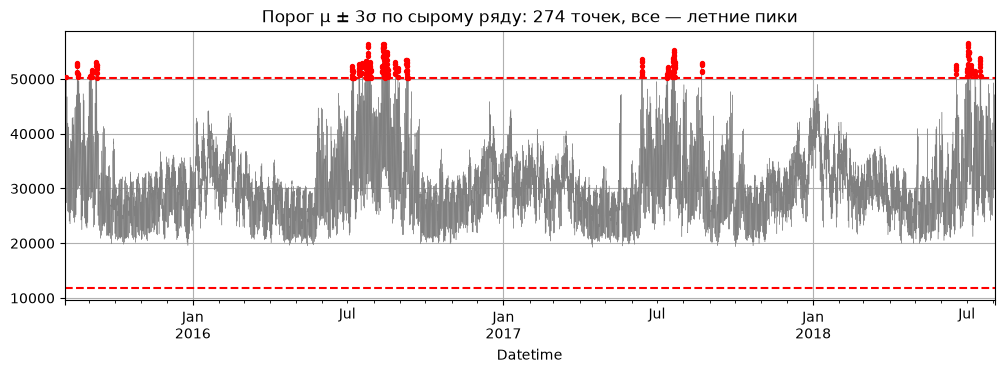

In [3]:
mu, sd = pjme.mean(), pjme.std()
raw_out = pjme[(pjme - mu).abs() > 3 * sd]

ax = pjme.plot(lw=0.3, color="gray", figsize=(12, 3.5))
ax.axhline(mu + 3 * sd, color="red", ls="--")
ax.axhline(mu - 3 * sd, color="red", ls="--")
ax.scatter(raw_out.index, raw_out, color="red", s=8, zorder=3)
ax.set_title(f"Порог μ ± 3σ по сырому ряду: {len(raw_out)} точек, все — летние пики");

### 1.1. Остаток MSTL + робастный порог

Убираем тренд и сезонности и ищем большие остатки. Порог считаем через
медиану и MAD (median absolute deviation): $\sigma$ остатка сам раздувается
выбросами, а MAD — нет. Множитель 1.4826 делает MAD оценкой $\sigma$ для нормального шума.

$$z_t = \frac{R_t - \mathrm{median}(R)}{1.4826\cdot\mathrm{MAD}(R)}, \qquad |z_t| > k \Rightarrow \text{аномалия}.$$

In [4]:
def mad_z(r):
    """Робастный z-score остатка."""
    med = r.median()
    return (r - med) / (1.4826 * (r - med).abs().median())


res = SMMSTL(pjme, periods=[24, 168]).fit()
z = mad_z(res.resid)

pd.DataFrame(
    {k: {"часов": (z.abs() > k).sum(), "дней": z[z.abs() > k].index.normalize().nunique()} for k in [3, 4, 5]}
).rename_axis("k", axis=1)

k,3,4,5
часов,951,236,70
дней,140,38,13


Гиперпараметр — множитель $k$: при $k=3$ отмечаем 140 дней из 1096, при $k=5$ — 13.
Берём $k=4$. Знак остатка различает типы аномалий: ниже нормы и выше нормы.

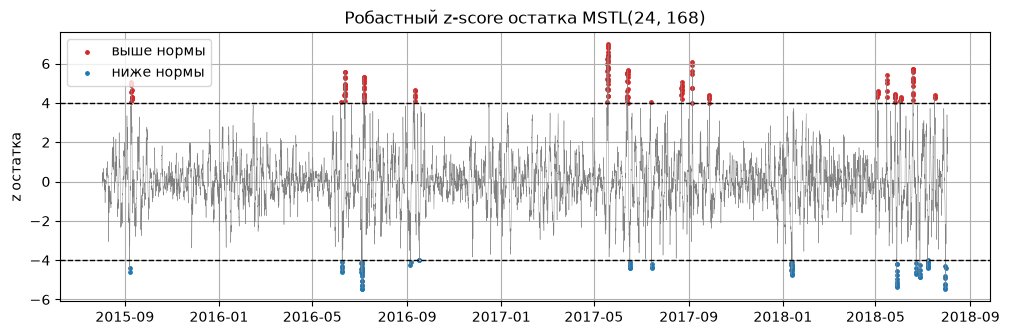

In [5]:
k = 4
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(z, lw=0.3, color="gray")
ax.scatter(z[z > k].index, z[z > k], s=6, color="tab:red", label="выше нормы")
ax.scatter(z[z < -k].index, z[z < -k], s=6, color="tab:blue", label="ниже нормы")
ax.axhline(k, color="black", ls="--", lw=1)
ax.axhline(-k, color="black", ls="--", lw=1)
ax.set_ylabel("z остатка")
ax.legend(loc="upper left")
ax.set_title("Робастный z-score остатка MSTL(24, 168)");

Сверим дни с аномалиями «ниже нормы» с федеральными праздниками США.

In [6]:
holidays = USFederalHolidayCalendar().holidays(pjme.index.min(), pjme.index.max())
daily_min = z.groupby(z.index.normalize()).min()
daily_max = z.groupby(z.index.normalize()).max()

low_days = daily_min[daily_min < -k].sort_values()
high_days = daily_max[daily_max > k].sort_values(ascending=False)
pd.DataFrame(
    {
        "ниже нормы": low_days.index.strftime("%Y-%m-%d %a").to_list()[:10],
        "праздник": low_days.index.isin(holidays)[:10],
        "выше нормы": high_days.index.strftime("%Y-%m-%d %a").to_list()[:10],
    }
)

,ниже нормы,праздник,выше нормы
0,2018-07-30 Mon,False,2017-05-19 Fri
1,2016-07-04 Mon,True,2017-05-18 Thu
2,2018-05-28 Mon,True,2017-09-05 Tue
3,2018-06-27 Wed,False,2018-06-18 Mon
4,2018-01-12 Fri,False,2017-06-13 Tue
5,2018-06-22 Fri,False,2016-06-12 Sun
6,2016-06-08 Wed,False,2018-05-15 Tue
7,2016-07-03 Sun,False,2016-07-06 Wed
8,2015-09-07 Mon,True,2015-09-09 Wed
9,2017-07-14 Fri,False,2017-08-22 Tue


- **Ниже нормы** — праздники (4 июля, Memorial Day, Labor Day): нагрузка как в выходной,
  а недельная сезонность ждёт будний день. Остальные дни — прохладные дни посреди жары.
- **Выше нормы** — волны жары (май–сентябрь).

Обе причины — праздники и погода — вне модели, поэтому они попадают в остаток.

Неделя с 4 июля 2016 крупным планом: ряд, «нормальный» уровень $T + S_{24} + S_{168}$ и найденные часы.

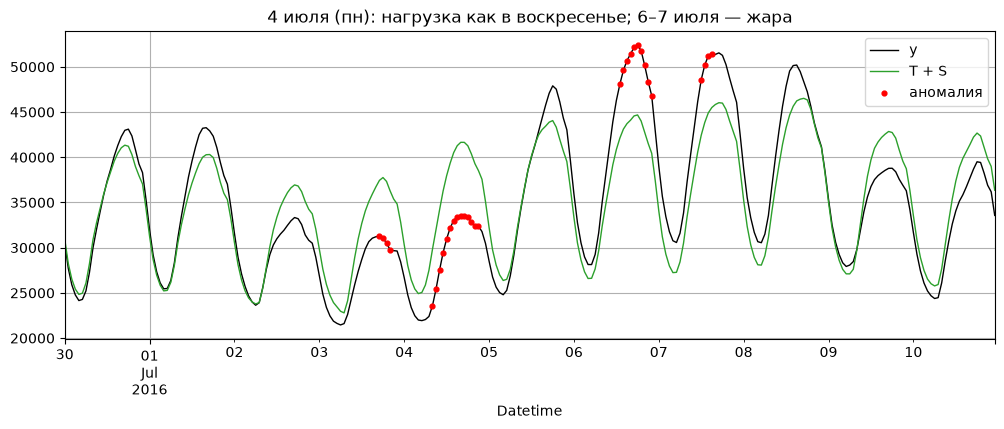

In [7]:
win = slice("2016-06-30", "2016-07-10")
normal = res.trend + res.seasonal.sum(axis=1)
anom = z[win][z[win].abs() > k].index

ax = pjme[win].plot(color="black", lw=1, label="y")
normal[win].plot(ax=ax, color="tab:green", lw=1, label="T + S")
ax.scatter(anom, pjme[anom], color="red", s=12, zorder=3, label="аномалия")
ax.legend()
ax.set_title("4 июля (пн): нагрузка как в воскресенье; 6–7 июля — жара");

### 1.2. Зачем `robust=True`: выброс протекает в сезонность

Проверим на ряде с известными аномалиями: добавим в elec_equip три выброса ±25
и найдём их по остатку STL ($k = 3.5$).

Без robust LOESS сезонности усредняет март 1997 вместе с соседними мартами. Выброс
сдвигает сезонность соседних лет и дает «эхо»: ложные аномалии в том же месяце в другие годы.
С robust точки с большими остатками получают вес ≈ 0, и сезонность их не видит.

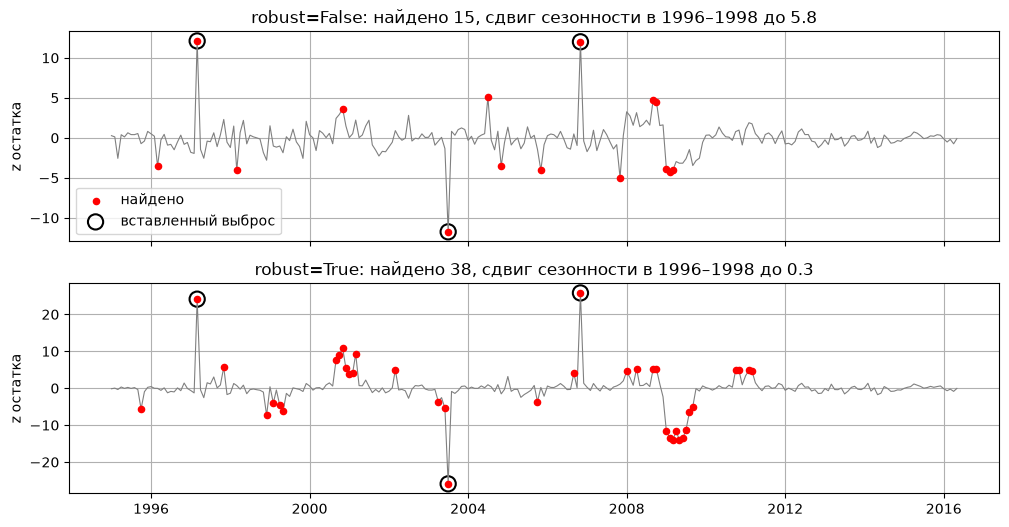

In [8]:
inj = pd.to_datetime(["1997-03-01", "2003-07-01", "2006-11-01"])
elec_inj = elec.copy()
elec_inj[inj] += [25, -25, 25]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, robust in zip(axes, [False, True]):
    r = STL(elec_inj, period=12, robust=robust).fit()
    zr = mad_z(r.resid)
    found = zr[zr.abs() > 3.5].index
    ax.plot(zr, color="gray", lw=0.8)
    ax.scatter(found, zr[found], color="red", s=20, zorder=3, label="найдено")
    ax.scatter(inj, zr[inj], facecolor="none", edgecolor="black", s=120, lw=1.5, label="вставленный выброс")
    shift = (r.seasonal - STL(elec, period=12, robust=robust).fit().seasonal).abs().loc["1996":"1998"].max()
    ax.set_title(f"robust={robust}: найдено {len(found)}, сдвиг сезонности в 1996–1998 до {shift:.1f}")
    ax.set_ylabel("z остатка")
axes[0].legend(loc="lower left");

- `robust=False`: остаток в точке выброса меньше (≈17 вместо 25), рядом с ним ложные срабатывания
  в марте 1996/1998, июле 2004, ноябре 2005/2007.
- `robust=True`: выбросы целиком в остатке, эха нет. Зато в аномалии попадают кризисы 2000–2001
  и 2008–2009: робастный тренд не следует за резким провалом. Для поиска аномалий это нормально,
  а для удаления компонент провал лучше оставить в тренде (см. п. 2.1).

### 1.3. statsforecast: выход за интервал in-sample прогноза

В statsforecast аномалии ищут по-другому
([туториал Nixtla](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/anomalydetection.html)):
обучаем вероятностную модель, берём in-sample прогнозы с интервалом и отмечаем `y` вне интервала.

`forecast(..., level=[99], fitted=True)` → `forecast_fitted_values()`.

In [9]:
sf_anom = StatsForecast(models=[MSTL(season_length=[24, 168])], freq="h")
sf_anom.forecast(df=df, h=24, level=[99], fitted=True)
fitted = sf_anom.forecast_fitted_values()
out_sf = fitted[~fitted["y"].between(fitted["MSTL-lo-99"], fitted["MSTL-hi-99"])]
fitted.head(3)

,unique_id,ds,y,MSTL,MSTL-lo-99,MSTL-hi-99
0,PJME,2018-04-01 00:00:00,24991.0,24986.9,24310.3,25663.4
1,PJME,2018-04-01 01:00:00,23687.0,23673.8,22997.3,24350.3
2,PJME,2018-04-01 02:00:00,22858.0,22832.0,22155.5,23508.5


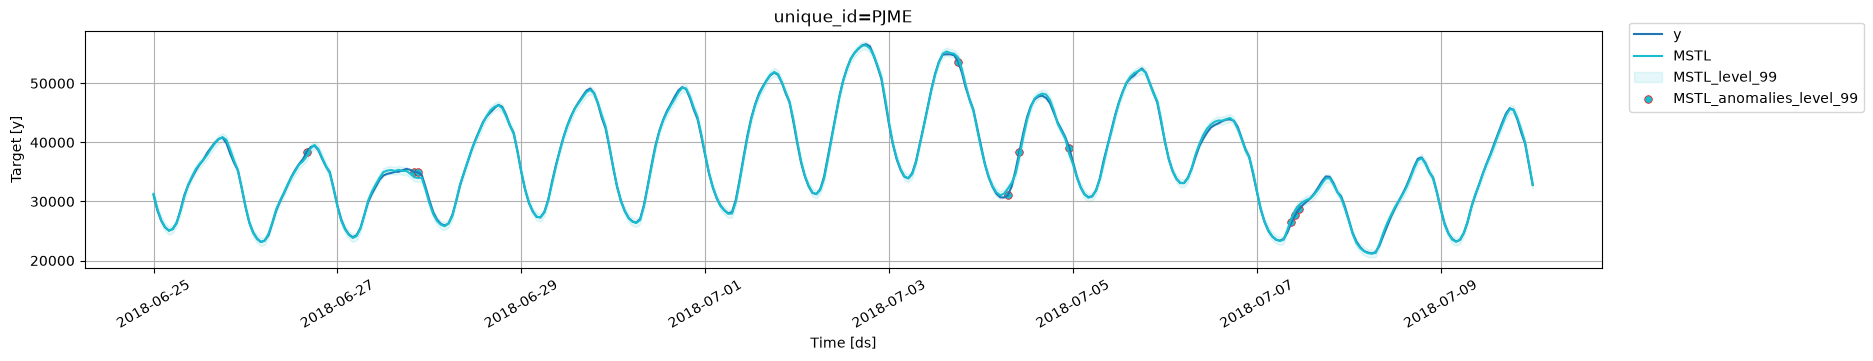

In [10]:
plot_series(
    forecasts_df=fitted[fitted["ds"].between("2018-06-25", "2018-07-10")],
    level=[99],
    plot_anomalies=True,
)

В `MSTL` интервал строит `trend_forecaster` (AutoETS) на ряде без сезонности, поэтому
аномалия здесь — большая **ошибка прогноза на шаг вперёд**, а не большой остаток разложения.
На час вперёд модель точна, поэтому интервал узкий (±700 МВт), а аномалии — резкие изломы
кривой внутри суток. Жаркие 2–3 июля не отмечены: модель подстраивается к уровню за пару часов.
Сравним множества на одном отрезке.

In [11]:
anom_mad = set(z.loc["2018-04-01":][z.loc["2018-04-01":].abs() > k].index)
anom_sf = set(out_sf["ds"])
pd.Series(
    {
        "остаток MSTL + MAD": len(anom_mad),
        "интервал statsforecast": len(anom_sf),
        "в обоих": len(anom_mad & anom_sf),
    },
    name="часов с аномалиями",
)

остаток MSTL + MAD        67
интервал statsforecast    70
в обоих                    8
Name: часов с аномалиями, dtype: int64

Пересечение маленькое: два подхода отвечают на разные вопросы. Остаток разложения —
«час не похож на обычный час этого дня недели», интервал — «скачок не предсказан за час до него».

## 2. Удаление компонент: прогноз $y - S$ и прогноз $S$

$$\hat y_{t+h} = \widehat{(T+R)}_{t+h} + \hat S_{t+h}.$$

- $\hat S$ — **сезонный наивный прогноз компоненты**: последний цикл $S$ повторяется
  (так в `STLForecast` и в `MSTL` statsforecast).
- $\widehat{T+R}$ — любая **несезонная** модель на сезонно скорректированном ряде $y - S$.

Модели для $y - S$ проще: не нужны сезонные лаги ARIMA. А с периодом 168
сезонная ARIMA уже не справляется, тогда как MSTL убирает обе сезонности.

### 2.1. statsmodels — `STLForecast`

`STLForecast(y, model, model_kwargs, **stl_kwargs)`: STL → `model(y - S, **model_kwargs)` →
прогноз модели + последний цикл $S$. На elec_equip держим последние 24 месяца как тест.

In [12]:
H = 24
tr, te = elec[:-H], elec[-H:]

stlf = STLForecast(tr, SMARIMA, model_kwargs={"order": (1, 1, 0), "trend": "t"}, period=12).fit()
fc_stl = stlf.forecast(H)
stlf.summary().tables[0]

Dep. Variable:,y,No. Observations:,233
Model:,"ARIMA(1, 1, 0)",Log Likelihood,-483.062
Date:,"Mon, 05 Oct 2026",AIC,972.124
Time:,08:33:56,BIC,982.464
Sample:,01-01-1995,HQIC,976.294
,- 05-01-2014,,
Covariance Type:,opg,,


Внутри — две части. Модель ARIMA видит только `y - S`; сезонность повторяется по последнему году.

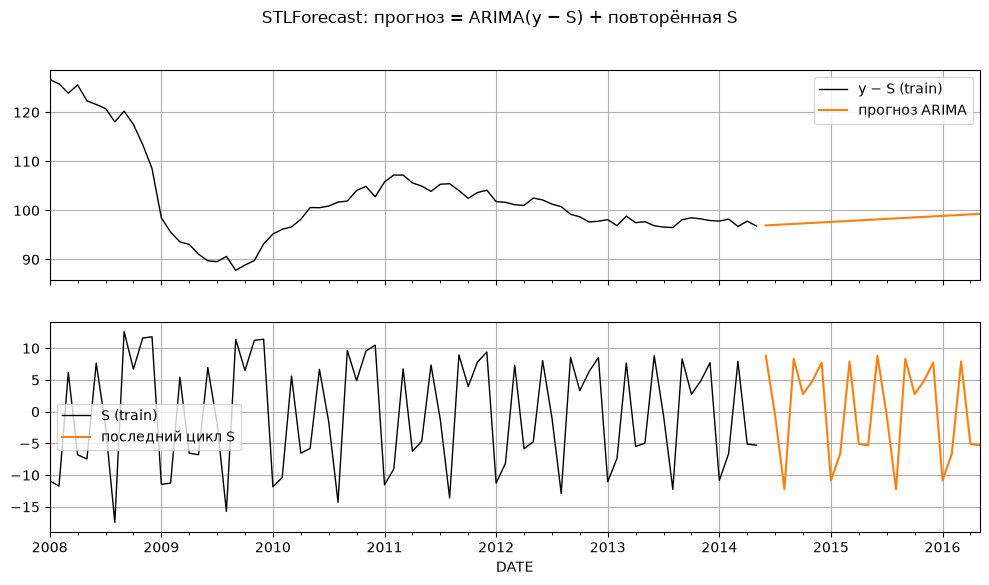

In [13]:
seas_adj = stlf.result.trend + stlf.result.resid
seas_fc = pd.Series(np.tile(stlf.result.seasonal[-12:], 2), index=te.index)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
seas_adj["2008":].plot(ax=axes[0], color="black", lw=1, label="y − S (train)")
(fc_stl - seas_fc).plot(ax=axes[0], color="tab:orange", label="прогноз ARIMA")
axes[0].legend()
stlf.result.seasonal["2008":].plot(ax=axes[1], color="black", lw=1, label="S (train)")
seas_fc.plot(ax=axes[1], color="tab:orange", label="последний цикл S")
axes[1].legend()
fig.suptitle("STLForecast: прогноз = ARIMA(y − S) + повторённая S");

Сравним с моделями на исходном ряде. Отдельно — `robust=True`: провал 2008–2009
не искажает сезонность, и последний цикл $S$ точнее.

STL(robust) + ARIMA(1,1,0)    2.9
STL + ARIMA(1,1,0)            3.2
Seasonal naive                3.8
STL + ETS(A,Ad,N)             5.1
SARIMA(1,1,0)(0,1,1)12        6.4
Name: MAE, dtype: float64

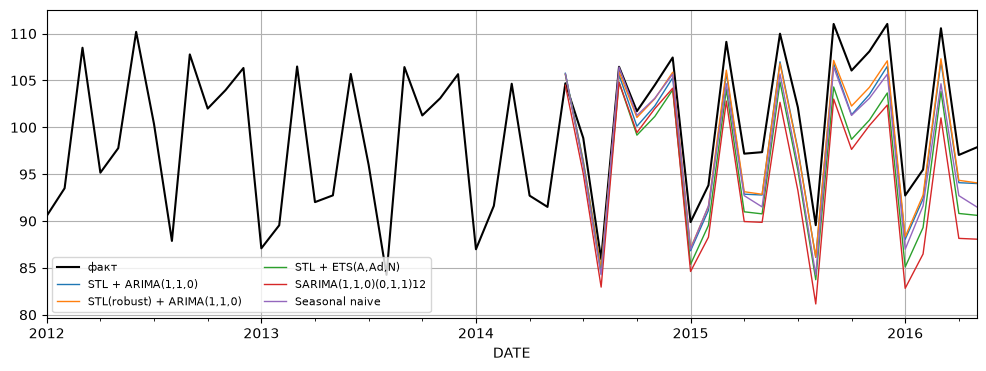

In [14]:
fcs = {
    "STL + ARIMA(1,1,0)": fc_stl,
    "STL(robust) + ARIMA(1,1,0)": STLForecast(
        tr, SMARIMA, model_kwargs={"order": (1, 1, 0), "trend": "t"}, period=12, robust=True
    ).fit().forecast(H),
    "STL + ETS(A,Ad,N)": STLForecast(
        tr, ETSModel, model_kwargs={"trend": "add", "damped_trend": True}, period=12
    ).fit().forecast(H),
    "SARIMA(1,1,0)(0,1,1)12": SMARIMA(tr, order=(1, 1, 0), seasonal_order=(0, 1, 1, 12)).fit().forecast(H),
    "Seasonal naive": pd.Series(np.tile(tr[-12:], 2), index=te.index),
}
ax = elec["2012":].plot(color="black", lw=1.5, label="факт")
for name, fc in fcs.items():
    fc.plot(ax=ax, lw=1, label=name)
ax.legend(fontsize=8, ncol=2)
pd.Series({name: np.mean(np.abs(te - fc)) for name, fc in fcs.items()}, name="MAE").sort_values()

Мультипликативную сезонность STL не умеет: она аддитивная по построению.
Решение то же, что для классики — прогнозируем $\log y$ и возвращаемся через $\exp$.
Без логарифма амплитуда прогноза AirPassengers занижена.

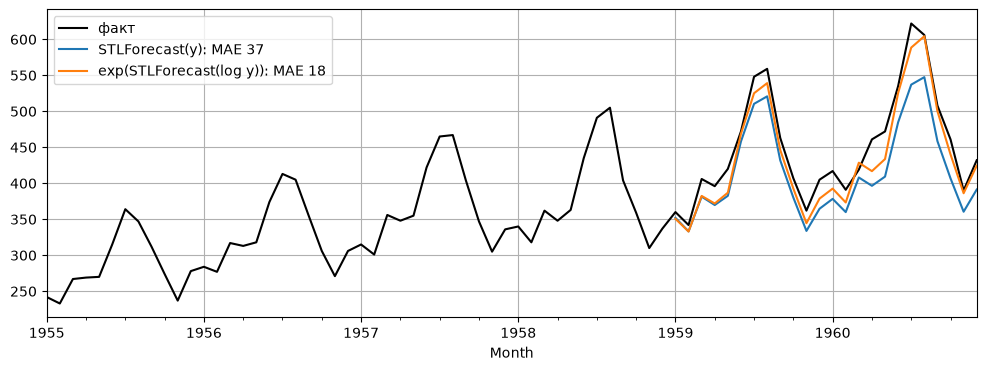

In [15]:
tr_a, te_a = air[:-H], air[-H:]
kw = dict(model_kwargs={"order": (1, 1, 0), "trend": "t"}, period=12)
fc_raw = STLForecast(tr_a, SMARIMA, **kw).fit().forecast(H)
fc_log = np.exp(STLForecast(np.log(tr_a), SMARIMA, **kw).fit().forecast(H))

ax = air["1955":].plot(color="black", lw=1.5, label="факт")
fc_raw.plot(ax=ax, label=f"STLForecast(y): MAE {np.mean(np.abs(te_a - fc_raw)):.0f}")
fc_log.plot(ax=ax, label=f"exp(STLForecast(log y)): MAE {np.mean(np.abs(te_a - fc_log)):.0f}")
ax.legend();

### 2.2. statsforecast — `MSTL`

`MSTL(season_length=[24, 168], trend_forecaster=AutoETS(model="ZZN"))` устроен так же:
- MSTL раскладывает ряд;
- `trend_forecaster` обучается на $T + R$ (название обманчиво — это не только тренд);
- сезонности повторяются по последнему циклу.

В дефолтном AutoETS сезонность запрещена (`"ZZN"`): её уже убрали.

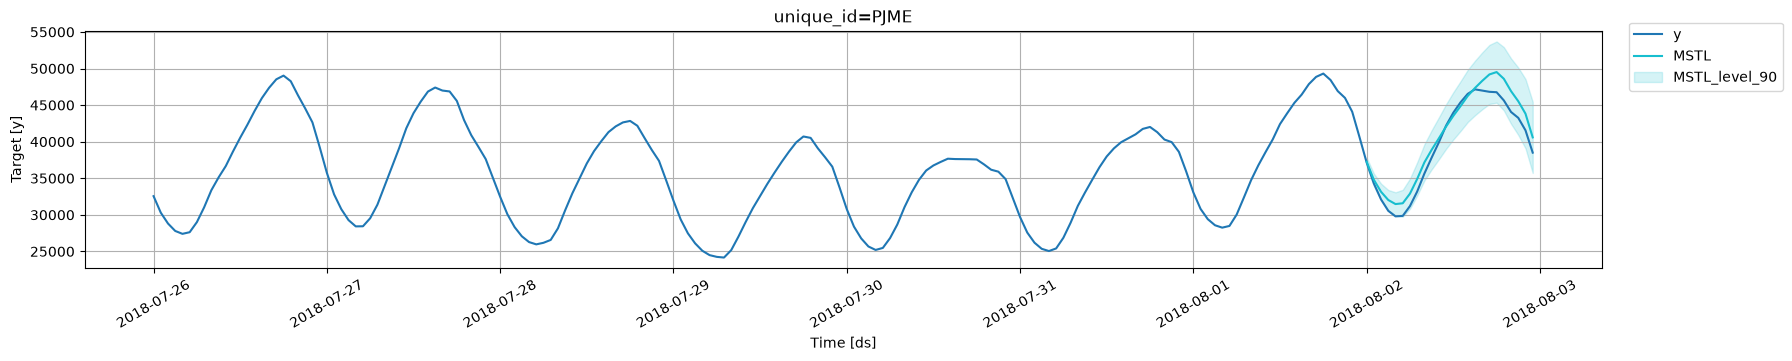

In [16]:
train, test = df.iloc[:-24], df.iloc[-24:]
sf_mstl = StatsForecast(models=[MSTL(season_length=[24, 168])], freq="h")
fc_mstl = sf_mstl.forecast(df=train, h=24, level=[90])
plot_series(train, fc_mstl.merge(test, on=["unique_id", "ds"]), level=[90], max_insample_length=24 * 7)

Компоненты, на которых обучен `trend_forecaster`, лежат в `.model_` обученной модели.

In [17]:
sf_mstl.fit(df=train)
comps = sf_mstl.fitted_[0, 0].model_
comps.tail(3)

,data,trend,seasonal24,seasonal168,remainder
2949,45985.0,34657.2,4129.0,667.0,6531.8
2950,44094.0,34647.3,2595.5,648.0,6203.2
2951,40666.0,34637.5,-311.4,624.7,5715.2


**Ловушка краёв.** Последний цикл $S$ — самая ненадёжная часть разложения: на краю
у LOESS только односторонние соседи. Посчитаем MSTL до момента прогноза и на всём ряде
и сравним $S_{24}$ за последние сутки train. На всём ряде сезонность за те же сутки другая:
разложение «пересмотрелось», когда пришли новые данные.

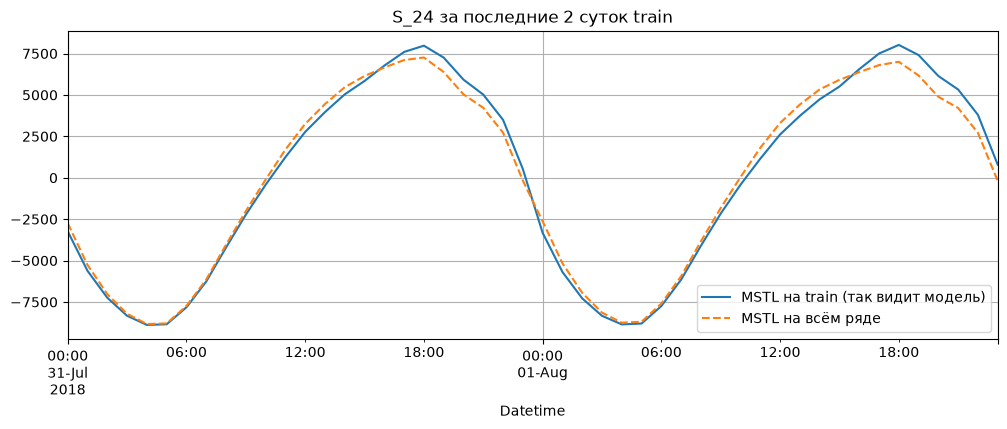

In [18]:
cut = train["ds"].iloc[-1]
s_train = SMMSTL(pjme[:cut], periods=[24, 168]).fit().seasonal["seasonal_24"]
s_full = SMMSTL(pjme, periods=[24, 168]).fit().seasonal["seasonal_24"]

last = slice(cut - pd.Timedelta(hours=47), cut)
ax = s_train[last].plot(label="MSTL на train (так видит модель)")
s_full[last].plot(ax=ax, label="MSTL на всём ряде", ls="--")
ax.legend()
ax.set_title("S_24 за последние 2 суток train");

Отсюда второе следствие: если разложить весь ряд и потом проверять прогноз,
компоненты на конце train уже «знают» будущее. В п. 3 покажем, как это завышает качество.

## 3. Компоненты как признаки

Вместо суммы компонент — регрессия на них. Модель сама выбирает вес тренда
и каждой сезонности и добавляет свою динамику ошибок.

`mstl_decomposition(df, MSTL(...), freq, h)` возвращает:
- `transformed_df` — исходный ряд с колонками `trend`, `seasonal24`, `seasonal168`;
- `X_df` — те же колонки на горизонте: тренд — прогноз `trend_forecaster`, сезонности — последний цикл.

In [19]:
train_X, future_X = mstl_decomposition(train, MSTL(season_length=[24, 168]), freq="h", h=24)
train_X.tail(3)

,unique_id,ds,y,trend,seasonal24,seasonal168
2949,PJME,2018-08-01 21:00:00,45985.0,34657.2,4129.0,667.0
2950,PJME,2018-08-01 22:00:00,44094.0,34647.3,2595.5,648.0
2951,PJME,2018-08-01 23:00:00,40666.0,34637.5,-311.4,624.7


In [20]:
future_X.head(3)

,unique_id,ds,trend,seasonal24,seasonal168
0,PJME,2018-08-02 00:00:00,40261.8,-2880.5,-109.5
1,PJME,2018-08-02 01:00:00,40170.8,-5295.3,-87.7
2,PJME,2018-08-02 02:00:00,40094.2,-6948.7,-1.6


ARIMA(2, 0, 1) с этими регрессорами против той же ARIMA без них. Коэффициенты
`ex_1..ex_3` (тренд, $S_{24}$, $S_{168}$) близки к 1: модель почти складывает компоненты,
а ARMA-часть описывает остаток.

{'ar1': np.float64(1.773), 'ar2': np.float64(-0.792), 'ma1': np.float64(0.227), 'intercept': np.float64(-1724.972), 'ex_1': np.float64(1.056), 'ex_2': np.float64(1.008), 'ex_3': np.float64(0.994)}


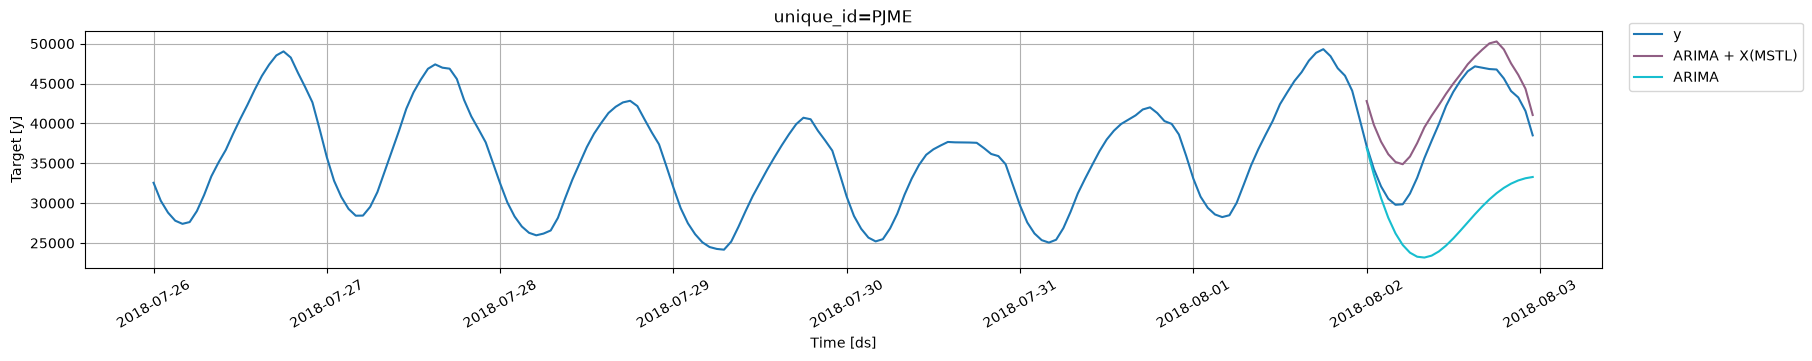

In [21]:
sf_x = StatsForecast(models=[ARIMA(order=(2, 0, 1), alias="ARIMA + X(MSTL)")], freq="h")
fc_x = sf_x.forecast(df=train_X, h=24, X_df=future_X)
fc_0 = StatsForecast(models=[ARIMA(order=(2, 0, 1), alias="ARIMA")], freq="h").forecast(df=train, h=24)

sf_x.fit(df=train_X)
print({name: round(v, 3) for name, v in sf_x.fitted_[0, 0].model_["coef"].items()})
plot_series(train, fc_x.merge(fc_0).merge(test), max_insample_length=24 * 7)

**Кросс-валидация без утечки.** `cross_validation` с `X_df` ждёт регрессоры, заданные
заранее для всего ряда. Наши регрессоры зависят от train, поэтому проходим окна сами:
на каждом окне — `mstl_decomposition` только на train.

In [22]:
def cv_mstl_features(df, model, n_windows, h=24):
    """CV для модели на компонентах MSTL: разложение заново на каждом окне."""
    cutoffs = df["ds"].iloc[-h * np.arange(n_windows, 0, -1) - 1]
    out = []
    for cutoff in cutoffs:
        tr = df[df["ds"] <= cutoff]
        te = df[df["ds"] > cutoff].head(h)
        tr_X, fut_X = mstl_decomposition(tr, MSTL(season_length=[24, 168]), freq="h", h=h)
        fc = StatsForecast(models=[model], freq="h").forecast(df=tr_X, h=h, X_df=fut_X)
        out.append(te.merge(fc, on=["unique_id", "ds"]).assign(cutoff=cutoff))
    return pd.concat(out, ignore_index=True)

**С утечкой** — разложение один раз на всём ряде, регрессоры на тесте взяты из него.

In [23]:
def cv_leaky(df, model, n_windows, h=24):
    """То же, но компоненты посчитаны на всём ряде — так делать нельзя."""
    full_X, _ = mstl_decomposition(df, MSTL(season_length=[24, 168]), freq="h", h=h)
    cutoffs = df["ds"].iloc[-h * np.arange(n_windows, 0, -1) - 1]
    out = []
    for cutoff in cutoffs:
        tr = full_X[full_X["ds"] <= cutoff]
        te = full_X[full_X["ds"] > cutoff].head(h)
        fc = StatsForecast(models=[model], freq="h").forecast(df=tr, h=h, X_df=te.drop(columns="y"))
        out.append(te[["unique_id", "ds", "y"]].merge(fc, on=["unique_id", "ds"]).assign(cutoff=cutoff))
    return pd.concat(out, ignore_index=True)

## 4. Сравнение

Кросс-валидация на PJME: прогноз на 24 часа, 7 окон (неделя), шаг 24 часа.

| Модель | Что делает |
|---|---|
| `SeasonalNaive(168)` | значение неделю назад — базовая линия |
| `ARIMA(2,0,1)(0,1,1)_{24}` | сезонная ARIMA на исходном ряде (только суточная сезонность) |
| `MSTL([24, 168])` + AutoETS / AutoARIMA / RWD | удаление сезонностей, разные `trend_forecaster` |
| `MSTL([24])` + AutoETS | недельную сезонность не убрали |
| ARIMA(2,0,1) | та же ARIMA без признаков |
| ARIMA(2,0,1) + X(MSTL) | компоненты как признаки |

`AutoARIMA(season_length=24)` на 3000 часовых точках не досчитывается за 7 минут,
поэтому сезонная ARIMA — с фиксированным порядком.

7 окон — одна неделя конца июля, жаркая. Разница в 5–10% между моделями на такой
выборке ненадёжна; уверенно можно говорить только о больших разрывах.

In [24]:
N_WINDOWS = 7
models = [
    SeasonalNaive(season_length=168),
    ARIMA(order=(2, 0, 1), alias="ARIMA"),
    ARIMA(order=(2, 0, 1), seasonal_order=(0, 1, 1), season_length=24, alias="SARIMA_24"),
    MSTL(season_length=[24, 168], alias="MSTL + AutoETS"),
    MSTL(season_length=[24, 168], trend_forecaster=AutoARIMA(), alias="MSTL + AutoARIMA"),
    MSTL(season_length=[24, 168], trend_forecaster=RandomWalkWithDrift(), alias="MSTL + RWD"),
    MSTL(season_length=[24], alias="MSTL_24 + AutoETS"),
]

cvs, times = [], {}
for model in models:
    t0 = time.perf_counter()
    cv = StatsForecast(models=[model], freq="h").cross_validation(df=df, h=24, step_size=24, n_windows=N_WINDOWS)
    times[repr(model)] = time.perf_counter() - t0
    cvs.append(cv.set_index(["unique_id", "ds", "cutoff", "y"]))

for name, fn in [("ARIMA + X(MSTL)", cv_mstl_features), ("ARIMA + X(MSTL), утечка", cv_leaky)]:
    t0 = time.perf_counter()
    cv = fn(df, ARIMA(order=(2, 0, 1), alias=name), N_WINDOWS)
    times[name] = time.perf_counter() - t0
    cvs.append(cv.set_index(["unique_id", "ds", "cutoff", "y"]))

cv = pd.concat(cvs, axis=1).reset_index()
cv.head(3)

,unique_id,ds,cutoff,y,SeasonalNaive,ARIMA,SARIMA_24,MSTL + AutoETS,MSTL + AutoARIMA,MSTL + RWD,MSTL_24 + AutoETS,ARIMA + X(MSTL),"ARIMA + X(MSTL), утечка"
0,PJME,2018-07-27 00:00:00,2018-07-26 23:00:00,35742.0,31740.0,35443.3,35748.8,36204.1,35950.9,36355.5,36696.6,37347.7,35672.6
1,PJME,2018-07-27 01:00:00,2018-07-26 23:00:00,32798.0,29098.0,32041.3,32884.6,33709.1,33290.7,34011.9,34273.3,34490.5,32801.9
2,PJME,2018-07-27 02:00:00,2018-07-26 23:00:00,30772.0,27369.0,29139.4,30891.3,31986.9,31471.0,32417.8,32580.1,32476.2,30797.3


In [25]:
first_train = df[df["ds"] <= cv["cutoff"].min()]
scores = (
    evaluate(cv.drop(columns="cutoff"), metrics=[mae, rmse, partial(mase, seasonality=168)], train_df=first_train)
    .drop(columns="unique_id")
    .set_index("metric")
    .T
)
scores["время, с"] = pd.Series(times).map("{:.1f}".format)
scores.sort_values("mae")

metric,mae,rmse,mase,"время, с"
"ARIMA + X(MSTL), утечка",1554.9,2378.2,0.4,0.7
MSTL_24 + AutoETS,1810.2,2320.7,0.5,0.9
MSTL + AutoARIMA,1912.2,2712.4,0.5,8.3
MSTL + AutoETS,1913.2,2591.7,0.5,3.1
SARIMA_24,2185.3,2837.0,0.6,8.2
ARIMA + X(MSTL),2214.6,2764.6,0.6,3.4
MSTL + RWD,2395.8,3043.2,0.6,2.5
SeasonalNaive,3357.8,4121.2,0.9,0.0
ARIMA,7499.6,9353.9,2.0,0.1


Вариант «с утечкой» выглядит лучшим, но это иллюзия: его регрессоры на тесте
посчитаны с учётом будущих значений. Честные выводы:
- все варианты с удалением сезонности заметно лучше `SeasonalNaive`;
- компоненты как признаки — самый большой эффект: ARIMA без них не видит сезонности
  и ошибается в разы сильнее, с ними — на уровне сезонной ARIMA;
- `trend_forecaster`: ETS и AutoARIMA близки, случайное блуждание с дрейфом хуже,
  AutoARIMA при этом в 2–3 раза дольше;
- `MSTL([24])` на этой неделе лучше `MSTL([24, 168])` — проверим, где именно.

In [26]:
weekend = cv["ds"].dt.dayofweek >= 5
cols = ["MSTL + AutoETS", "MSTL_24 + AutoETS", "SARIMA_24"]
(cv[cols].sub(cv["y"], axis=0).abs().groupby(weekend.map({False: "будни", True: "выходные"})).mean())

,MSTL + AutoETS,MSTL_24 + AutoETS,SARIMA_24
ds,,,
будни,2061.1,1810.2,2026.0
выходные,1543.5,1810.3,2583.4


Недельная сезонность окупается на выходных: там `MSTL([24, 168])` ошибается меньше всех,
а `SARIMA_24`, которая выходных не знает, — больше всех. В будни `MSTL([24])` выигрывает:
средний будний профиль $S_{168}$ оценён по прохладным неделям и мешает в жару.
Чтобы выбрать между ними, нужна CV длиннее одной недели.

Прогнозы на трёх последних окнах.

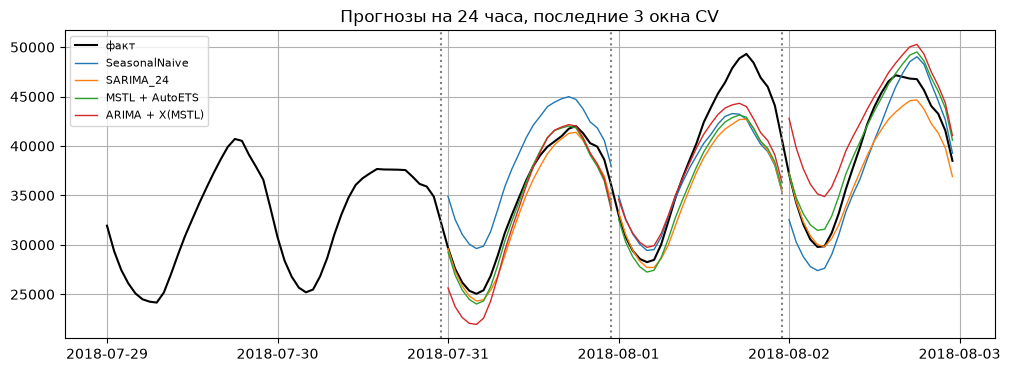

In [27]:
show = ["SeasonalNaive", "SARIMA_24", "MSTL + AutoETS", "ARIMA + X(MSTL)"]
last_cutoffs = cv["cutoff"].drop_duplicates().iloc[-3:]
part = cv[cv["cutoff"].isin(last_cutoffs)]

fact = df.set_index("ds")["y"].loc[part["ds"].min() - pd.Timedelta(days=2):]
fig, ax = plt.subplots()
ax.plot(fact.index, fact, color="black", lw=1.5, label="факт")
for name in show:
    for i, (_, g) in enumerate(part.groupby("cutoff")):
        ax.plot(g["ds"], g[name], lw=1, color=f"C{show.index(name)}", label=name if i == 0 else None)
for c in last_cutoffs:
    ax.axvline(c, color="gray", ls=":")
ax.legend(fontsize=8)
ax.set_title("Прогнозы на 24 часа, последние 3 окна CV");

## 5. Итоги

| Задача | Что берём из разложения | Инструмент | Главная ловушка |
|---|---|---|---|
| Аномалии | остаток $R$, порог по MAD | `STL`/`MSTL` statsmodels; `forecast_fitted_values` statsforecast | без `robust` выброс протекает в сезонность («эхо»); погода и праздники вне модели — тоже «аномалии» |
| Удаление компонент | $y - S$ → любая несезонная модель; $\hat S$ — последний цикл | `STLForecast`; `MSTL(trend_forecaster=...)` | последний цикл $S$ на краю нестабилен; мультипликативный ряд — сначала $\log$ |
| Признаки | $T, S_{24}, S_{168}$ как регрессоры | `mstl_decomposition` + модель с X | разложение всего ряда до разбиения → утечка, завышенное качество |

**Мостик к Theta.** `Theta(season_length=m, decomposition_type="multiplicative")` делает то же
внутри: классическая декомпозиция → прогноз ряда без сезонности → возврат $S$.